(200, 2) (200,)


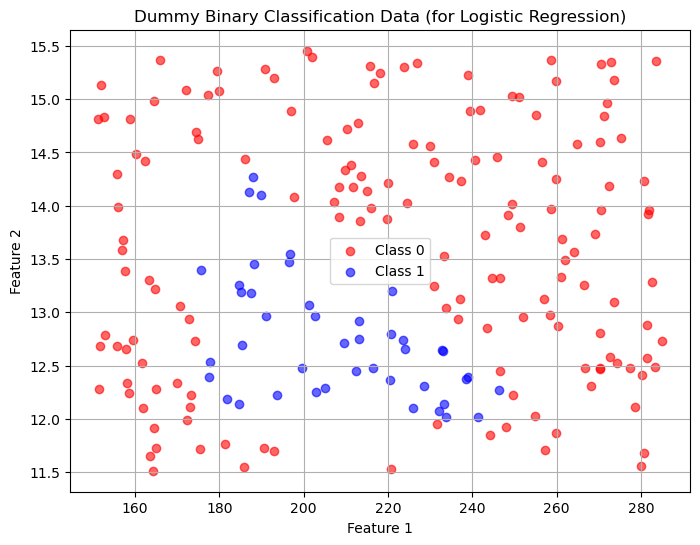

In [28]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y)

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
from sklearn.preprocessing import PolynomialFeatures


y=np.where(y==0,-1,1)
y=y.reshape(-1,1)
m=len(X)

X = (X - X.mean(axis=0))/X.std(axis=0)

poly = PolynomialFeatures(degree=8, include_bias=False)
X = poly.fit_transform(X)

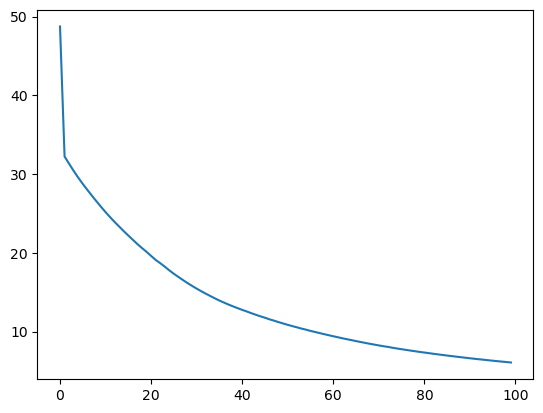

In [34]:
w=np.random.randn(1,X.shape[1])
b=0
loss_history=[]
alpha=0.01
c=15

for epochs in range(100):
    margin=1-y*(w@X.T+b).T
    hinge_loss=c*np.mean(np.maximum(0,margin))
    total_loss=(1/2)*np.sum(np.square(w))+hinge_loss
    
    loss_history.append(total_loss)
    
    mask=(margin>0).flatten()
    djdw= w - (1/m)*c*np.sum(X[mask]*y[mask], axis=0,keepdims=True)
    djdb=-c*np.mean(y[mask])
    
    
    w=w - alpha *djdw
    b=b- alpha*djdb

plt.plot(loss_history)

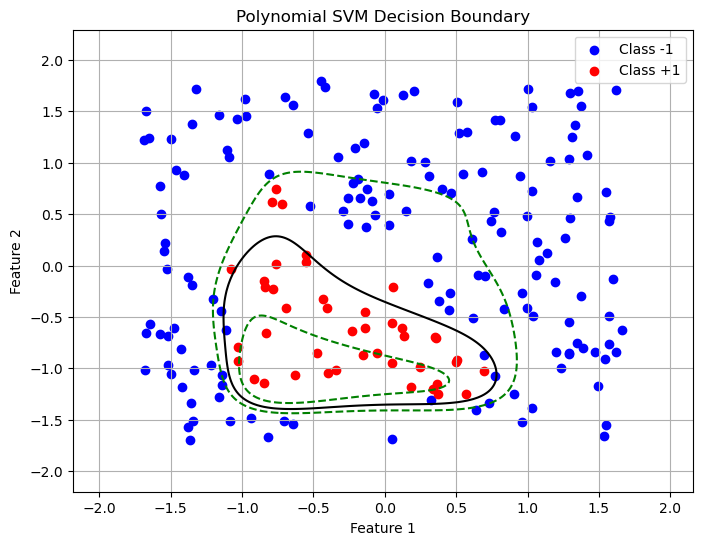

In [35]:
# Decision Boundary

plt.figure(figsize=(8,6))

# Mesh Grid
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Convert grid into polynomial features
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid)

# SVM score
Z = (w @ grid_poly.T + b).reshape(xx.shape)

# Decision boundary
plt.contour(xx, yy, Z,
            levels=[-1,0,1],
            colors=['green','black','green'],
            linestyles=['--','-','--'])

# Data points
plt.scatter(
    X[y[:,0]==-1][:,0],
    X[y[:,0]==-1][:,1],
    c='blue',
    label='Class -1'
)

plt.scatter(
    X[y[:,0]==1][:,0],
    X[y[:,0]==1][:,1],
    c='red',
    label='Class +1'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()